In [ ]:
!pip install -q transformers datasets scikit-learn accelerate sentencepiece

In [ ]:
import gc
import json
import os
from tqdm import tqdm
import random
import time
import warnings
from collections import Counter

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, Dataset as TorchDataset
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    f1_score,
)
from sklearn.model_selection import train_test_split
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    get_cosine_schedule_with_warmup,
)

warnings.filterwarnings("ignore")

In [ ]:
os.environ["HF_TOKEN"] = "******************"

In [ ]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device : {DEVICE}")
if DEVICE.type == "cuda":
    print(f"GPU    : {torch.cuda.get_device_name(0)}")
    print(f"VRAM   : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

Device : cuda
GPU    : Tesla T4
VRAM   : 15.6 GB


In [ ]:
MODEL_NAME = "AIMH/mental-xlnet-base-cased"
NUM_LABELS = 9

CONFIG = {
    "summary_csv"  : "/content/summarized_output.csv",
    "train_json"   : "/content/train.json",
    "test_csv"     : "/content/summarized_output_test.csv",
    "output_dir"   : "/content/MentalXlnet",

    "max_seq_length": 512,
    "num_epochs"    : 15,
    "batch_size"    : 8,
    "grad_accum"    : 4,
    "learning_rate" : 2e-5,
    "weight_decay"  : 0.01,

    "val_frac"      : 0.10,
    "l7_target"     : 550,
}

In [ ]:
os.makedirs(CONFIG["output_dir"], exist_ok=True)

LABEL_NAMES = {
    0: "L0: No Defense",
    1: "L1: Action",
    2: "L2: Major Image-Distort",
    3: "L3: Disavowal",
    4: "L4: Minor Image-Distort",
    5: "L5: Neurotic",
    6: "L6: Obsessional",
    7: "L7: High-Adaptive",
    8: "L8: Needs More Info",
}
EVAL_LABELS = list(range(9))


In [ ]:
train_json_df     = pd.read_json(CONFIG["train_json"])
id_to_dialogue_id = dict(zip(train_json_df["id"], train_json_df["dialogue_id"]))

train_raw              = pd.read_csv(CONFIG["summary_csv"])
train_raw["dialogue_id"] = train_raw["id"].map(id_to_dialogue_id)
train_raw["label"]       = train_raw["label"].astype(int)

print(f"  Raw train rows : {len(train_raw)}")
print(f"\nLabel distribution (raw):")
for lbl, cnt in sorted(Counter(train_raw["label"].values).items()):
    bar = "█" * int(cnt / len(train_raw) * 40)
    print(f"  {LABEL_NAMES[lbl]:<35} {cnt:>4} ({cnt/len(train_raw)*100:4.1f}%) {bar}")

  Raw train rows : 1864

Label distribution (raw):
  L0: No Defense                       296 (15.9%) ██████
  L1: Action                           108 ( 5.8%) ██
  L2: Major Image-Distort               61 ( 3.3%) █
  L3: Disavowal                         99 ( 5.3%) ██
  L4: Minor Image-Distort               84 ( 4.5%) █
  L5: Neurotic                          48 ( 2.6%) █
  L6: Obsessional                      172 ( 9.2%) ███
  L7: High-Adaptive                    968 (51.9%) ████████████████████
  L8: Needs More Info                   28 ( 1.5%) 


In [ ]:
_, val_idx = train_test_split(
    range(len(train_raw)),
    test_size   = CONFIG["val_frac"],
    random_state= SEED,
    stratify    = train_raw["label"].values,
)
val_df   = train_raw.iloc[val_idx].reset_index(drop=True)
train_df = train_raw.drop(index=val_idx).reset_index(drop=True)

print(f"\n  Train : {len(train_df)}  |  Val : {len(val_df)}")
print(f"  Val label coverage: {sorted(val_df['label'].unique().tolist())}")


  Train : 1677  |  Val : 187
  Val label coverage: [0, 1, 2, 3, 4, 5, 6, 7, 8]


In [ ]:
# undersampling of L7
l7_count  = (train_df["label"] == 7).sum()
l7_target = min(CONFIG["l7_target"], l7_count)

train_df_bal = pd.concat([
    train_df[train_df["label"] != 7],
    train_df[train_df["label"] == 7].sample(n=l7_target, random_state=SEED),
], ignore_index=True).sample(frac=1, random_state=SEED).reset_index(drop=True)

l7_pct = Counter(train_df_bal["label"].values)[7] / len(train_df_bal) * 100
print(f"\nAfter L7 undersampling: {len(train_df_bal)} samples  (L7={l7_pct:.1f}%)")


After L7 undersampling: 1356 samples  (L7=40.6%)


In [ ]:
def compute_class_weights(df, n_classes=9):
    counts = Counter(df["label"].values)
    N = len(df)
    w = {c: N / (n_classes * max(counts.get(c, 1), 1)) for c in range(n_classes)}
    return torch.tensor([w[c] for c in range(n_classes)], dtype=torch.float32)

class_weight_tensor = compute_class_weights(train_df_bal)
print("\nClass weights:")
for c in range(9):
    print(f"  {LABEL_NAMES[c]:<35} w={class_weight_tensor[c]:.3f}")



Class weights:
  L0: No Defense                      w=0.566
  L1: Action                          w=1.553
  L2: Major Image-Distort             w=2.739
  L3: Disavowal                       w=1.693
  L4: Minor Image-Distort             w=1.982
  L5: Neurotic                        w=3.504
  L6: Obsessional                     w=0.972
  L7: High-Adaptive                   w=0.274
  L8: Needs More Info                 w=6.027


In [ ]:
def build_text(summary: str, current_text: str) -> str:

    return str(summary).strip(), str(current_text).strip()

In [ ]:
class DefenseDataset(TorchDataset):
    def __init__(self, df: pd.DataFrame, tokenizer, max_len: int, has_labels=True):
        self.df         = df.reset_index(drop=True)
        self.tokenizer  = tokenizer
        self.max_len    = max_len
        self.has_labels = has_labels

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        text_a, text_b = build_text(row["summary"], row["current_text"])

        enc = self.tokenizer(
            text_a,
            text_b,
            max_length      = self.max_len,
            padding         = "max_length",
            truncation      = True,
            return_tensors  = "pt",
        )

        item = {
            "input_ids"     : enc["input_ids"].squeeze(0),
            "attention_mask": enc["attention_mask"].squeeze(0),
        }
        if self.has_labels:
            item["labels"] = torch.tensor(int(row["label"]), dtype=torch.long)
        return item


In [ ]:
print(f"\nLoading tokenizer: {MODEL_NAME}")
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
print(f"  Vocab size: {tokenizer.vocab_size}")

print(f"Loading model: {MODEL_NAME}")
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=NUM_LABELS,
    torch_dtype=torch.float32,
    ignore_mismatched_sizes=True,
)

model = model.float()





Loading tokenizer: AIMH/mental-xlnet-base-cased


config.json:   0%|          | 0.00/921 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/489 [00:00<?, ?B/s]

spiece.model:   0%|          | 0.00/798k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

  Vocab size: 32000
Loading model: AIMH/mental-xlnet-base-cased


`torch_dtype` is deprecated! Use `dtype` instead!


pytorch_model.bin:   0%|          | 0.00/467M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/206 [00:00<?, ?it/s]

XLNetForSequenceClassification LOAD REPORT from: AIMH/mental-xlnet-base-cased
Key                             | Status     | 
--------------------------------+------------+-
lm_loss.bias                    | UNEXPECTED | 
lm_loss.weight                  | UNEXPECTED | 
sequence_summary.summary.bias   | MISSING    | 
sequence_summary.summary.weight | MISSING    | 
logits_proj.bias                | MISSING    | 
logits_proj.weight              | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [ ]:
model.to(DEVICE)
total_params = sum(p.numel() for p in model.parameters())
print(f"  Parameters : {total_params/1e6:.1f}M")

train_dataset = DefenseDataset(train_df_bal, tokenizer, CONFIG["max_seq_length"])
val_dataset   = DefenseDataset(val_df,       tokenizer, CONFIG["max_seq_length"])

model.safetensors:   0%|          | 0.00/467M [00:00<?, ?B/s]

  Parameters : 117.3M


In [ ]:
train_loader = DataLoader(
    train_dataset,
    batch_size = CONFIG["batch_size"],
    shuffle    = True,
    num_workers= 2,
    pin_memory = True,
)
val_loader = DataLoader(
    val_dataset,
    batch_size = CONFIG["batch_size"] * 2,
    shuffle    = False,
    num_workers= 2,
    pin_memory = True,
)
print(f"\nDataLoaders ready.")
print(f"  Train batches : {len(train_loader)}")
print(f"  Val   batches : {len(val_loader)}")


DataLoaders ready.
  Train batches : 170
  Val   batches : 12


In [ ]:
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr           = CONFIG["learning_rate"],
    weight_decay = CONFIG["weight_decay"],
)

total_steps  = (len(train_loader) // CONFIG["grad_accum"]) * CONFIG["num_epochs"]
warmup_steps = max(1, int(total_steps * 0.06))

scheduler = get_cosine_schedule_with_warmup(
    optimizer,
    num_warmup_steps  = warmup_steps,
    num_training_steps= total_steps,
)

loss_fn = nn.CrossEntropyLoss(
    weight    = class_weight_tensor.to(DEVICE),
    reduction = "mean",
)

print(f"\nOptimizer  : AdamW  lr={CONFIG['learning_rate']}  wd={CONFIG['weight_decay']}")
print(f"Total steps: {total_steps}  Warmup: {warmup_steps}")


Optimizer  : AdamW  lr=2e-05  wd=0.01
Total steps: 630  Warmup: 37


In [ ]:
def evaluate(mdl, loader):
    mdl.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for batch in loader:
            batch   = {k: v.to(DEVICE) for k, v in batch.items()}
            labels  = batch.pop("labels")
            outputs = mdl(**batch)
            preds   = outputs.logits.argmax(dim=-1)
            all_preds .extend(preds.cpu().tolist())
            all_labels.extend(labels.cpu().tolist())
    macro_f1 = f1_score(all_labels, all_preds, labels=EVAL_LABELS,
                        average="macro", zero_division=0)
    acc = accuracy_score(all_labels, all_preds)
    return macro_f1, acc, all_labels, all_preds

In [ ]:
print(f"  Epochs      : {CONFIG['num_epochs']}")
print(f"  Batch size  : {CONFIG['batch_size']}  (grad_accum={CONFIG['grad_accum']})")


best_f1       = 0.0
best_epoch    = 0
history       = []
all_step_losses = []


model = model.float()
model = model.to(DEVICE)
for epoch in range(1, CONFIG["num_epochs"] + 1):
    model.train()
    optimizer.zero_grad()
    epoch_losses = []
    t0 = time.time()

    progress_bar = tqdm(train_loader, desc=f"Epoch {epoch:02d}/{CONFIG['num_epochs']}")

    for step, batch in enumerate(progress_bar, 1):
        batch  = {k: v.to(DEVICE) for k, v in batch.items()}
        labels = batch.pop("labels")

        outputs = model(**batch)
        loss    = loss_fn(outputs.logits.float(), labels)
        loss    = loss / CONFIG["grad_accum"]
        loss.backward()

        epoch_losses.append(loss.item() * CONFIG["grad_accum"])
        all_step_losses.append(loss.item() * CONFIG["grad_accum"])

        if step % CONFIG["grad_accum"] == 0:
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            scheduler.step()
            optimizer.zero_grad()

        # ── update progress bar ──
        avg_loss = sum(epoch_losses[-50:]) / min(len(epoch_losses), 50)
        progress_bar.set_postfix({
            "loss": f"{avg_loss:.4f}",
            "lr"  : f"{scheduler.get_last_lr()[0]:.2e}",
        })

    # ── Epoch validation ──────────────────────────────────────────────────
    macro_f1, acc, true_l, pred_l = evaluate(model, val_loader)
    elapsed = time.time() - t0
    is_best = macro_f1 > best_f1

    history.append({"epoch": epoch, "f1": macro_f1, "acc": acc,
                    "loss": np.mean(epoch_losses)})

    marker = "← NEW BEST" if is_best else f"(best: {best_f1:.4f})"
    print(f"Epoch {epoch:02d}/{CONFIG['num_epochs']}  "
          f"loss={np.mean(epoch_losses):.4f}  "
          f"val_F1={macro_f1:.4f} {marker}  "
          f"acc={acc:.4f}  {elapsed:.0f}s")

    if is_best:
        best_f1    = macro_f1
        best_epoch = epoch
        best_path  = os.path.join(CONFIG["output_dir"], "best_model")
        model.save_pretrained(best_path)
        tokenizer.save_pretrained(best_path)
        print(f"Saved → {best_path}")

  Epochs      : 15
  Batch size  : 8  (grad_accum=4)



Epoch 01/15: 100%|██████████| 170/170 [02:52<00:00,  1.01s/it, loss=2.1803, lr=2.00e-05]


Epoch 01/15  loss=2.2232  val_F1=0.1528 ← NEW BEST  acc=0.3904  183s


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved → /content/MentalXlnet/best_model


...

Epoch 13/15  loss=0.2318  val_F1=0.2534 (best: 0.2812)  acc=0.5401  190s


Epoch 14/15: 100%|██████████| 170/170 [02:59<00:00,  1.05s/it, loss=0.2174, lr=2.47e-07]


Epoch 14/15  loss=0.2139  val_F1=0.2527 (best: 0.2812)  acc=0.5401  190s


Epoch 15/15: 100%|██████████| 170/170 [02:58<00:00,  1.05s/it, loss=0.2113, lr=0.00e+00]


Epoch 15/15  loss=0.2106  val_F1=0.2522 (best: 0.2812)  acc=0.5401  190s


In [ ]:
state = {
    "best_val_f1"  : best_f1,
    "best_epoch"   : best_epoch,
    "model_name"   : MODEL_NAME,
    "history"      : history,
}
with open(os.path.join(CONFIG["output_dir"], "training_state.json"), "w") as f:
    json.dump(state, f, indent=2)

print(f"  Best val Macro F1 : {best_f1:.4f}  (epoch {best_epoch})")
for h in history:
    mark = " ← BEST" if h["epoch"] == best_epoch else ""
    print(f"    Epoch {h['epoch']:02d}: F1={h['f1']:.4f}  acc={h['acc']:.4f}  "
          f"loss={h['loss']:.4f}{mark}")


  Best val Macro F1 : 0.2812  (epoch 6)
    Epoch 01: F1=0.1528  acc=0.3904  loss=2.2232
    Epoch 02: F1=0.1673  acc=0.3583  loss=1.9452
    Epoch 03: F1=0.2152  acc=0.4813  loss=1.6684
    Epoch 04: F1=0.2507  acc=0.4866  loss=1.4239
    Epoch 05: F1=0.2434  acc=0.4492  loss=1.1948
    Epoch 06: F1=0.2812  acc=0.4920  loss=0.9620 ← BEST
    Epoch 07: F1=0.2381  acc=0.4920  loss=0.7636
    Epoch 08: F1=0.2628  acc=0.5080  loss=0.6035
    Epoch 09: F1=0.2594  acc=0.5241  loss=0.4618
    Epoch 10: F1=0.2596  acc=0.5401  loss=0.3723
    Epoch 11: F1=0.2703  acc=0.5455  loss=0.3101
    Epoch 12: F1=0.2568  acc=0.5508  loss=0.2587
    Epoch 13: F1=0.2534  acc=0.5401  loss=0.2318
    Epoch 14: F1=0.2527  acc=0.5401  loss=0.2139
    Epoch 15: F1=0.2522  acc=0.5401  loss=0.2106


In [ ]:
print(f"\n{'='*60}")
print("VALIDATION REPORT")
print(f"{'='*60}")

best_model = AutoModelForSequenceClassification.from_pretrained(
    best_path, num_labels=NUM_LABELS
).to(DEVICE)
macro_f1, acc, true_l, pred_l = evaluate(best_model, val_loader)

print(f"Accuracy : {acc:.4f}")
print(f"Macro F1 : {macro_f1:.4f}")
print(classification_report(
    true_l, pred_l,
    labels       = EVAL_LABELS,
    target_names = [LABEL_NAMES[i] for i in range(9)],
    digits       = 4,
    zero_division= 0,
))


VALIDATION REPORT


Loading weights:   0%|          | 0/210 [00:00<?, ?it/s]

Accuracy : 0.4920
Macro F1 : 0.2812
                         precision    recall  f1-score   support

         L0: No Defense     0.6591    0.9667    0.7838        30
             L1: Action     0.2143    0.2727    0.2400        11
L2: Major Image-Distort     0.2143    0.5000    0.3000         6
          L3: Disavowal     0.1667    0.1000    0.1250        10
L4: Minor Image-Distort     0.0000    0.0000    0.0000         8
           L5: Neurotic     0.1250    0.2000    0.1538         5
        L6: Obsessional     0.2857    0.3529    0.3158        17
      L7: High-Adaptive     0.7778    0.5052    0.6125        97
    L8: Needs More Info     0.0000    0.0000    0.0000         3

               accuracy                         0.4920       187
              macro avg     0.2714    0.3219    0.2812       187
           weighted avg     0.5669    0.4920    0.5067       187



In [ ]:
test_df = pd.read_csv(CONFIG["test_csv"])
test_df["label"] = test_df["label"].astype(int)
print(f"Test samples: {len(test_df)}")

test_dataset = DefenseDataset(
    test_df, tokenizer, CONFIG["max_seq_length"], has_labels=True
)
test_loader = DataLoader(
    test_dataset,
    batch_size = CONFIG["batch_size"] * 2,
    shuffle    = False,
    num_workers= 2,
    pin_memory = True,
)

macro_f1_test, acc_test, true_test, pred_test = evaluate(best_model, test_loader)

print(f"Accuracy : {acc_test:.4f}")
print(f"Macro F1 : {macro_f1_test:.4f}")
print(classification_report(
    true_test, pred_test,
    labels       = EVAL_LABELS,
    target_names = [LABEL_NAMES[i] for i in range(9)],
    digits       = 4,
    zero_division= 0,
))


output_df = test_df.copy()
output_df["prediction"] = pred_test
output_df.to_csv(os.path.join(CONFIG["output_dir"], "predictions.csv"), index=False)
print(f"\nPredictions saved → {CONFIG['output_dir']}/predictions.csv")

Test samples: 472
Accuracy : 0.5106
Macro F1 : 0.2965
                         precision    recall  f1-score   support

         L0: No Defense     0.6311    0.8667    0.7303        75
             L1: Action     0.1892    0.2500    0.2154        28
L2: Major Image-Distort     0.1667    0.3125    0.2174        16
          L3: Disavowal     0.0000    0.0000    0.0000        25
L4: Minor Image-Distort     0.0833    0.1429    0.1053        21
           L5: Neurotic     0.0000    0.0000    0.0000        13
        L6: Obsessional     0.3725    0.4318    0.4000        44
      L7: High-Adaptive     0.7989    0.5720    0.6667       243
    L8: Needs More Info     0.2727    0.4286    0.3333         7

               accuracy                         0.5106       472
              macro avg     0.2794    0.3338    0.2965       472
           weighted avg     0.5709    0.5106    0.5263       472


Predictions saved → /content/MentalXlnet/predictions.csv


In [ ]:
test_df = pd.read_csv(CONFIG["test_csv"])
test_df["label"] = test_df["label"].astype(int)
print(f"Test samples: {len(test_df)}")

test_dataset = DefenseDataset(
    test_df, tokenizer, CONFIG["max_seq_length"], has_labels=True
)
test_loader = DataLoader(
    test_dataset,
    batch_size = CONFIG["batch_size"] * 2,
    shuffle    = False,
    num_workers= 2,
    pin_memory = True,
)

# Get predictions
macro_f1_test, acc_test, true_test, pred_test = evaluate(best_model, test_loader)

# ============================================================
# REPORT 1: ALL LABELS (0-8) - Clinical Setting
# ============================================================
print(f"\n{'='*60}")
print("REPORT 1: ALL LABELS (0-8) - Clinical Setting")
print(f"{'='*60}")
print(f"Accuracy : {acc_test:.4f}")
print(f"Macro F1 : {macro_f1_test:.4f}")
print(classification_report(
    true_test, pred_test,
    labels       = EVAL_LABELS,
    target_names = [LABEL_NAMES[i] for i in range(9)],
    digits       = 4,
    zero_division= 0,
))

# ============================================================
# REPORT 2: EXCLUDING L0 (1-8) - Defense-Focused Setting
# ============================================================
print(f"\n{'='*60}")
print("REPORT 2: EXCLUDING L0 (1-8) - Defense-Focused Setting")
print(f"{'='*60}")

# Filter out L0 (label 0)
mask_1_8 = [label != 0 for label in true_test]
true_test_1_8 = [true_test[i] for i in range(len(true_test)) if mask_1_8[i]]
pred_test_1_8 = [pred_test[i] for i in range(len(pred_test)) if mask_1_8[i]]

# Calculate metrics for 1-8
acc_1_8 = accuracy_score(true_test_1_8, pred_test_1_8)
macro_f1_1_8 = f1_score(true_test_1_8, pred_test_1_8,
                         labels=range(1, 9),
                         average='macro',
                         zero_division=0)

print(f"Accuracy (1-8) : {acc_1_8:.4f}")
print(f"Macro F1 (1-8) : {macro_f1_1_8:.4f}")
print(f"Samples (excluding L0): {len(true_test_1_8)} / {len(true_test)}")
print(classification_report(
    true_test_1_8, pred_test_1_8,
    labels       = range(1, 9),  # Only labels 1-8
    target_names = [LABEL_NAMES[i] for i in range(1, 9)],  # Skip L0
    digits       = 4,
    zero_division= 0,
))

# ============================================================
# COMPARISON SUMMARY
# ============================================================
print(f"\n{'='*60}")
print("COMPARISON SUMMARY")
print(f"{'='*60}")
print(f"Metric          | 0-8 (All) | 1-8 (No L0) | Difference")
print(f"-----------------|-----------|-------------|-----------")
print(f"Accuracy         | {acc_test:.4f}    | {acc_1_8:.4f}     | {acc_1_8 - acc_test:+.4f}")
print(f"Macro F1         | {macro_f1_test:.4f}    | {macro_f1_1_8:.4f}     | {macro_f1_1_8 - macro_f1_test:+.4f}")

# ============================================================
# PER-CLASS F1 COMPARISON
# ============================================================
print(f"\n{'='*60}")
print("PER-CLASS F1 COMPARISON")
print(f"{'='*60}")

# Calculate per-class F1 for all labels
from sklearn.metrics import f1_score
f1_per_class_all = f1_score(true_test, pred_test, labels=range(9), average=None, zero_division=0)

print(f"{'Class':<25} | {'F1 Score':<8} | Notes")
print(f"{'-'*25}-|-{'-'*8}-|-{'-'*20}")
for i in range(9):
    note = ""
    if i == 0:
        note = "← Included in 0-8 only"
    elif i == 7:
        note = "← Majority class"
    elif i in [2, 3, 5, 8]:
        note = "← Hard class"
    print(f"{LABEL_NAMES[i]:<25} | {f1_per_class_all[i]:.4f}   | {note}")

# ============================================================
# SAVE PREDICTIONS
# ============================================================
output_df = test_df.copy()
output_df["prediction"] = pred_test
output_df.to_csv(os.path.join(CONFIG["output_dir"], "predictions.csv"), index=False)
print(f"\n✅ Predictions saved → {CONFIG['output_dir']}/predictions.csv")

Test samples: 472

REPORT 1: ALL LABELS (0-8) - Clinical Setting
Accuracy : 0.5106
Macro F1 : 0.2965
                         precision    recall  f1-score   support

         L0: No Defense     0.6311    0.8667    0.7303        75
             L1: Action     0.1892    0.2500    0.2154        28
L2: Major Image-Distort     0.1667    0.3125    0.2174        16
          L3: Disavowal     0.0000    0.0000    0.0000        25
L4: Minor Image-Distort     0.0833    0.1429    0.1053        21
           L5: Neurotic     0.0000    0.0000    0.0000        13
        L6: Obsessional     0.3725    0.4318    0.4000        44
      L7: High-Adaptive     0.7989    0.5720    0.6667       243
    L8: Needs More Info     0.2727    0.4286    0.3333         7

               accuracy                         0.5106       472
              macro avg     0.2794    0.3338    0.2965       472
           weighted avg     0.5709    0.5106    0.5263       472


REPORT 2: EXCLUDING L0 (1-8) - Defense-Focused Set

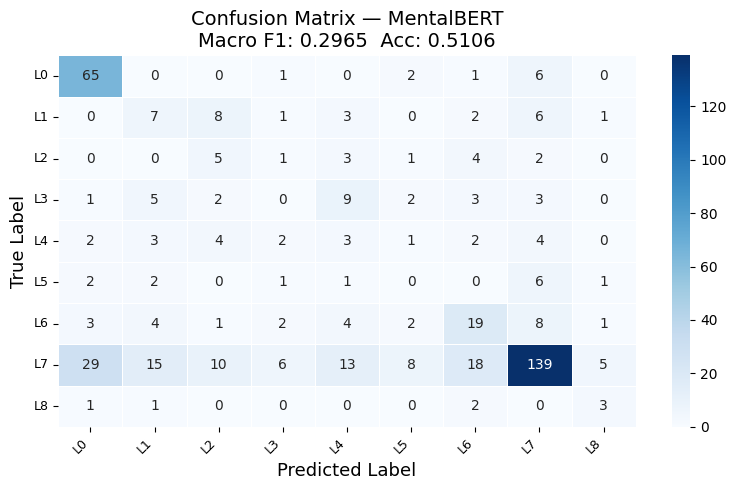

Confusion matrix saved → /content/MentalXlnet/confusion_matrix.png


In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

label_names_short = ["L0", "L1", "L2", "L3", "L4", "L5", "L6", "L7", "L8"]

cm = confusion_matrix(true_test, pred_test, labels=EVAL_LABELS)

fig, ax = plt.subplots(figsize=(8, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=label_names_short,
    yticklabels=label_names_short,
    ax=ax,
    linewidths=0.5,
)

ax.set_xlabel("Predicted Label", fontsize=13)
ax.set_ylabel("True Label", fontsize=13)
ax.set_title(f"Confusion Matrix — MentalBERT\nMacro F1: {macro_f1_test:.4f}  Acc: {acc_test:.4f}", fontsize=14)
plt.xticks(rotation=45, ha="right", fontsize=9)
plt.yticks(rotation=0, fontsize=9)
plt.tight_layout()

cm_path = os.path.join(CONFIG["output_dir"], "confusion_matrix.png")
plt.savefig(cm_path, dpi=150)
plt.show()
print(f"Confusion matrix saved → {cm_path}")

In [ ]:
xlnet_df = pd.read_csv("/content/MentalXlnet/predictions.csv")
true_labels = xlnet_df['label'].values
xlnet_preds = xlnet_df['prediction'].values

In [ ]:
label_names_short = ["L0", "L1", "L2", "L3", "L4", "L5", "L6", "L7", "L8"]

xlnet_correct = (xlnet_preds == true_labels)
xlnet_wrong = ~xlnet_correct

In [ ]:
print(f"Total samples: {len(true_labels)}")
print(f"Correct: {xlnet_correct.sum()} ({xlnet_correct.mean()*100:.1f}%)")
print(f"Wrong: {xlnet_wrong.sum()} ({xlnet_wrong.mean()*100:.1f}%)")


Total samples: 472
Correct: 241 (51.1%)
Wrong: 231 (48.9%)


In [ ]:
class_stats = {}
for label in range(9):
    mask = (true_labels == label)
    total = mask.sum()
    correct = (xlnet_preds[mask] == true_labels[mask]).sum()
    wrong = total - correct
    error_rate = wrong / total if total > 0 else 0

    class_stats[label] = {
        'total': total,
        'correct': correct,
        'wrong': wrong,
        'error_rate': error_rate
    }

    print(f"\n{LABEL_NAMES[label]}:")
    print(f"  Total samples: {total}")
    print(f"  Correct: {correct} ({correct/total*100:.1f}%)" if total > 0 else "  Correct: 0")
    print(f"  Wrong: {wrong} ({error_rate*100:.1f}%)" if total > 0 else "  Wrong: 0")


L0: No Defense:
  Total samples: 75
  Correct: 65 (86.7%)
  Wrong: 10 (13.3%)

L1: Action:
  Total samples: 28
  Correct: 7 (25.0%)
  Wrong: 21 (75.0%)

L2: Major Image-Distort:
  Total samples: 16
  Correct: 5 (31.2%)
  Wrong: 11 (68.8%)

L3: Disavowal:
  Total samples: 25
  Correct: 0 (0.0%)
  Wrong: 25 (100.0%)

L4: Minor Image-Distort:
  Total samples: 21
  Correct: 3 (14.3%)
  Wrong: 18 (85.7%)

L5: Neurotic:
  Total samples: 13
  Correct: 0 (0.0%)
  Wrong: 13 (100.0%)

L6: Obsessional:
  Total samples: 44
  Correct: 19 (43.2%)
  Wrong: 25 (56.8%)

L7: High-Adaptive:
  Total samples: 243
  Correct: 139 (57.2%)
  Wrong: 104 (42.8%)

L8: Needs More Info:
  Total samples: 7
  Correct: 3 (42.9%)
  Wrong: 4 (57.1%)


In [ ]:
for true_label in range(9):
    mask = (true_labels == true_label) & xlnet_wrong
    wrong_samples = xlnet_preds[mask]

    if len(wrong_samples) > 0:
        print(f"\n{LABEL_NAMES[true_label]} was misclassified as:")
        unique, counts = np.unique(wrong_samples, return_counts=True)
        for pred, count in sorted(zip(unique, counts), key=lambda x: x[1], reverse=True):
            pct = count / len(wrong_samples) * 100
            print(f"  → {LABEL_NAMES[pred]}: {count} ({pct:.1f}%)")


L0: No Defense was misclassified as:
  → L7: High-Adaptive: 6 (60.0%)
  → L5: Neurotic: 2 (20.0%)
  → L3: Disavowal: 1 (10.0%)
  → L6: Obsessional: 1 (10.0%)

L1: Action was misclassified as:
  → L2: Major Image-Distort: 8 (38.1%)
  → L7: High-Adaptive: 6 (28.6%)
  → L4: Minor Image-Distort: 3 (14.3%)
  → L6: Obsessional: 2 (9.5%)
  → L3: Disavowal: 1 (4.8%)
  → L8: Needs More Info: 1 (4.8%)

L2: Major Image-Distort was misclassified as:
  → L6: Obsessional: 4 (36.4%)
  → L4: Minor Image-Distort: 3 (27.3%)
  → L7: High-Adaptive: 2 (18.2%)
  → L3: Disavowal: 1 (9.1%)
  → L5: Neurotic: 1 (9.1%)

L3: Disavowal was misclassified as:
  → L4: Minor Image-Distort: 9 (36.0%)
  → L1: Action: 5 (20.0%)
  → L6: Obsessional: 3 (12.0%)
  → L7: High-Adaptive: 3 (12.0%)
  → L2: Major Image-Distort: 2 (8.0%)
  → L5: Neurotic: 2 (8.0%)
  → L0: No Defense: 1 (4.0%)

L4: Minor Image-Distort was misclassified as:
  → L2: Major Image-Distort: 4 (22.2%)
  → L7: High-Adaptive: 4 (22.2%)
  → L1: Action: 3 (1

In [ ]:
mb_df = pd.read_csv("/content/predictions_mentalbert_3121.csv")
mb_preds = mb_df['prediction'].values

print("\n" + "="*70)
print("4. XLNet vs MentalBERT - PER-CLASS COMPARISON")
print("="*70)
print(f"{'Class':<25} | {'MB F1':<8} | {'XLNet F1':<8} | {'Diff':<8} | {'Winner':<12}")
print("-"*70)

mb_report = classification_report(true_labels, mb_preds, output_dict=True, zero_division=0)
xlnet_report = classification_report(true_labels, xlnet_preds, output_dict=True, zero_division=0)

for i in range(9):
    i_str = str(i)
    mb_f1 = mb_report[i_str]['f1-score']
    xlnet_f1 = xlnet_report[i_str]['f1-score']
    diff = xlnet_f1 - mb_f1
    winner = "XLNet" if diff > 0 else "MB" if diff < 0 else "Tie"
    symbol = "✅" if diff > 0.01 else "❌" if diff < -0.01 else "➖"
    print(f"{LABEL_NAMES[i]:<25} | {mb_f1:.4f}   | {xlnet_f1:.4f}   | {diff:+.4f}   | {winner:<12} {symbol}")


4. XLNet vs MentalBERT - PER-CLASS COMPARISON
Class                     | MB F1    | XLNet F1 | Diff     | Winner      
----------------------------------------------------------------------
L0: No Defense            | 0.7467   | 0.7303   | -0.0163   | MB           ❌
L1: Action                | 0.2540   | 0.2154   | -0.0386   | MB           ❌
L2: Major Image-Distort   | 0.2353   | 0.2174   | -0.0179   | MB           ❌
L3: Disavowal             | 0.1212   | 0.0000   | -0.1212   | MB           ❌
L4: Minor Image-Distort   | 0.2000   | 0.1053   | -0.0947   | MB           ❌
L5: Neurotic              | 0.0714   | 0.0000   | -0.0714   | MB           ❌
L6: Obsessional           | 0.2222   | 0.4000   | +0.1778   | XLNet        ✅
L7: High-Adaptive         | 0.6911   | 0.6667   | -0.0245   | MB           ❌
L8: Needs More Info       | 0.2667   | 0.3333   | +0.0667   | XLNet        ✅


Mental-XLNet significantly outperformed MentalBERT on L6 (Obsessional defenses, +17.8% F1) and L8 (Needs More Information, +6.7% F1). This suggests XLNet's permutation language modeling better captures intellectualization and ambiguity marker

In [ ]:
test_df = pd.read_csv("/content/summarized_output_test.csv")

# Find worst-performing classes
worst_classes = sorted(class_stats.items(), key=lambda x: x[1]['error_rate'], reverse=True)[:3]

for label, stats in worst_classes:
    if stats['wrong'] > 0:
        print(f"\n--- {LABEL_NAMES[label]} (Error Rate: {stats['error_rate']*100:.1f}%) ---")

        # Get misclassified examples for this class
        mask = (true_labels == label) & xlnet_wrong
        error_indices = np.where(mask)[0]

        for i, idx in enumerate(error_indices[:3]):  # Show up to 3 examples
            row = test_df.iloc[idx]
            print(f"\n  Example {i+1}:")
            print(f"  True: {LABEL_NAMES[label]}")
            print(f"  Pred: {LABEL_NAMES[xlnet_preds[idx]]}")
            print(f"  Summary: {str(row['summary'])[:150]}...")
            print(f"  Text: {str(row['current_text'])[:150]}...")


--- L3: Disavowal (Error Rate: 100.0%) ---

  Example 1:
  True: L3: Disavowal
  Pred: L5: Neurotic
  Summary: The seeker expresses deep, pervasive depression, describing life as awful, boring, and repetitive, wishing for an asteroid to end it. They feel trappe...
  Text: I would say that is fairly accurate. Often times, I wish an asteroid would come down and begin the apocolypse. Something to break up the routine Don't...

  Example 2:
  True: L3: Disavowal
  Pred: L7: High-Adaptive
  Summary: The Seeker expresses depression, attributing it to the pandemic and loneliness due to distance from family and partner. The Supporter identifies isola...
  Text: I suppose. I just worry that I will make them sad too. It's hard time for everyone....

  Example 3:
  True: L3: Disavowal
  Pred: L6: Obsessional
  Summary: The seeker struggles with body shaming, job loss due to COVID, poor mental health, and lack of support. The supporter advises stepping away from negat...
  Text: due to winter i a

In [ ]:
total_errors = xlnet_wrong.sum()
print(f"\nTotal errors: {total_errors} ({total_errors/len(true_labels)*100:.1f}%)")

# Categorize errors
confused_with_L7 = ((true_labels != 7) & (xlnet_preds == 7)).sum()
confused_with_L0 = ((true_labels != 0) & (xlnet_preds == 0)).sum()
missed_L7 = ((true_labels == 7) & (xlnet_preds != 7)).sum()

print(f"\nMajor error patterns:")
print(f"  - Wrongly predicted L7 (Adaptive): {confused_with_L7} times")
print(f"  - Wrongly predicted L0 (No Defense): {confused_with_L0} times")
print(f"  - Missed L7 (should have predicted L7): {missed_L7} times")


Total errors: 231 (48.9%)

Major error patterns:
  - Wrongly predicted L7 (Adaptive): 35 times
  - Wrongly predicted L0 (No Defense): 38 times
  - Missed L7 (should have predicted L7): 104 times
